In [9]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv("titles.csv")

Data Loading

This is the stage where we load our dataset using the 'read_csv()' function. The dataset includes details on the features of movies and shows on Netflix, which include runtime, year of release, rating, and popularity score, among others.
Dataset loading enables us to perform data exploration prior to training our machine learning model.

In [11]:
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [12]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64

Exploring the Data

Exploring the data before a machine learning model is essential.

df.head() to output the first few entries in the data.

df.shape to see the number of rows and columns.

df.info() to know about the data type and null/non-null entries.

df.describe() to get descriptive statistics of numerical variables.

df.isnull().sum() to find out any null values.

This helps detect any problems that could be caused by a lack of information.

In [13]:
print(df.columns)

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')


In [14]:
df = df.dropna(subset=['imdb_score','tmdb_score','tmdb_popularity'])

In [15]:
print(df['type'].unique())

['MOVIE' 'SHOW']


In [16]:
df = pd.read_csv("titles.csv")

print(df['type'].value_counts())

type
MOVIE    3744
SHOW     2106
Name: count, dtype: int64


In [17]:
df = pd.read_csv("titles.csv")

#check values
print(df['type'].unique())

#convert to uppercase
df['type'] = df['type'].str.upper()

print(df['type'].unique())

['SHOW' 'MOVIE']
['SHOW' 'MOVIE']


Data Cleaning

There are some categorical data values in the type column, which indicate whether the title is a movie or TV show.
    
Machine learning models cannot handle categorical data; therefore, we convert the data into numeric form as follows

This is known as label encoding, and now we can use this variable for our predictions.

In [18]:
features = df[['runtime','release_year','imdb_score','tmdb_score','tmdb_popularity']]
target = df['type']

Feature Selection

This phase involves selecting appropriate numerical features to train the machine learning model.

There are some of the factors that define each movie or TV show, thus possibly affecting whether it is one or the other.
The target variable is the type feature.    

In [19]:
print(features.head())
print(target.head())

   runtime  release_year  imdb_score  tmdb_score  tmdb_popularity
0       51          1945         NaN         NaN            0.600
1      114          1976         8.2       8.179           40.965
2      109          1972         7.7       7.300           10.010
3       91          1975         8.2       7.811           15.461
4      150          1967         7.7       7.600           20.398
0     SHOW
1    MOVIE
2    MOVIE
3    MOVIE
4    MOVIE
Name: type, dtype: object


In [20]:
#Splitting the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

Splitting of the Dataset

The splitting of the dataset is done by using the train_test_split () method.

80% of the data is used for training the machine learning algorithm, while 20% of the data is reserved for testing the model.

It helps in evaluating the performance of the machine learning model on new data.

In [21]:
#training the Machine Learning Model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Model Training

Training is done using a Random Forest Classifier algorithm.

The Random Forest Classifier algorithm is an ensemble learning technique that trains many decision trees and combines their predictions for improved results.

The training process involves the use of a training set dataset.

In [22]:
#making predictions
predictions = model.predict(X_test)

In [23]:
#Evaluating model performance
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.935042735042735


In [24]:
#hyperparameter tuning 

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


Tuning Hyperparameters

Hyperparameter tuning is done using GridSearchCV to determine the optimal set of model parameters.

The hyperparameters tuned are as follows:

Number of estimators

Depth of the tree

The purpose of this is to enhance model performance.

In [25]:
tuned_predictions = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(y_test, tuned_predictions)

print("Tuned Model Accuracy:", tuned_accuracy)

Tuned Model Accuracy: 0.935042735042735


In [26]:
#model inferencing(making prediction)
sample_data = X_test.iloc[0:5]

prediction = best_model.predict(sample_data)

print("Sample Predictions:", prediction)

Sample Predictions: ['SHOW' 'MOVIE' 'MOVIE' 'MOVIE' 'MOVIE']


Model Inferencing

The term inferencing pertains to applying the model to produce a prediction on unseen inputs.

A portion from the test set is employed in generating predictions and confirming that the model successfully classifies titles.

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, tuned_predictions)
print(cm)

print(classification_report(y_test, tuned_predictions))

[[716  48]
 [ 28 378]]
              precision    recall  f1-score   support

       MOVIE       0.96      0.94      0.95       764
        SHOW       0.89      0.93      0.91       406

    accuracy                           0.94      1170
   macro avg       0.92      0.93      0.93      1170
weighted avg       0.94      0.94      0.94      1170



In [28]:
!pip install seaborn

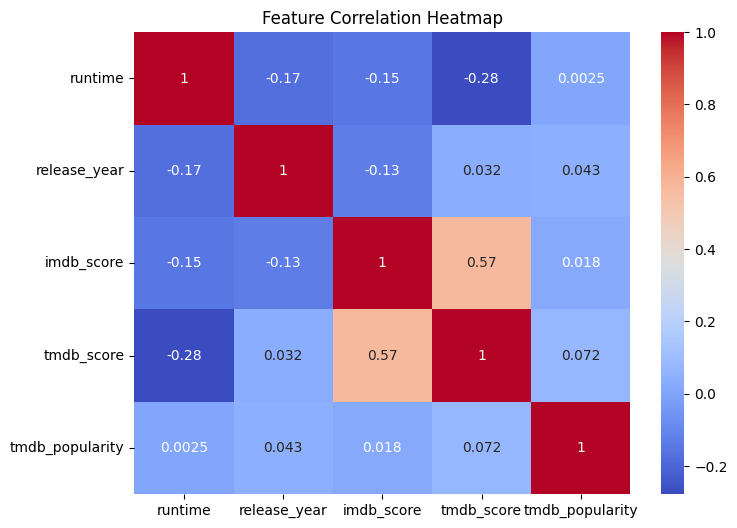

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

correlation = df[['runtime','release_year','imdb_score','tmdb_score','tmdb_popularity']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

Feature Correlation Heatmap
Correlation heat map is the tool to visualize the correlation between various numeric columns in the data set.
The correlation heat map will show correlation coefficients between the values -1 and 1:
Coefficients close to 1 will depict high positive correlation.
Coefficients close to -1 will depict high negative correlation.
Coefficients close to 0 will depict low or no correlation.
Such visual representation will enable us to determine the factors having maximum impact on the output column.

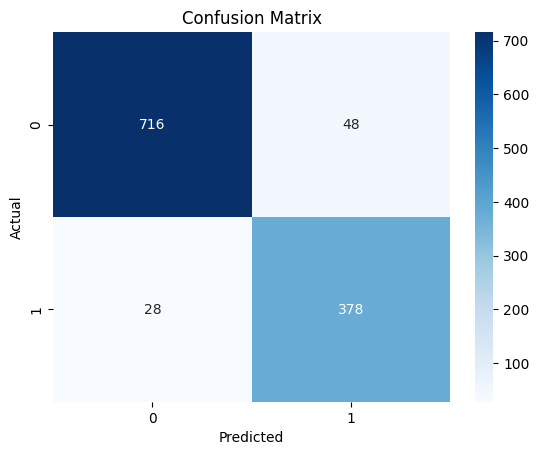

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

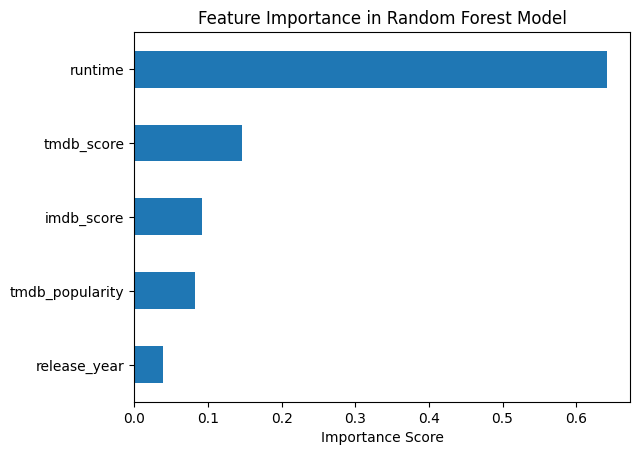

In [33]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.Series(importance, index=features.columns)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance Score")

plt.show()

Feature importance is related to the extent that each feature helps in making predictions using the machine learning model.
Random Forest computes the feature importance according to how important each feature is for building decision trees.
Important features will be those that are more influential in predicting movie or TV show titles.

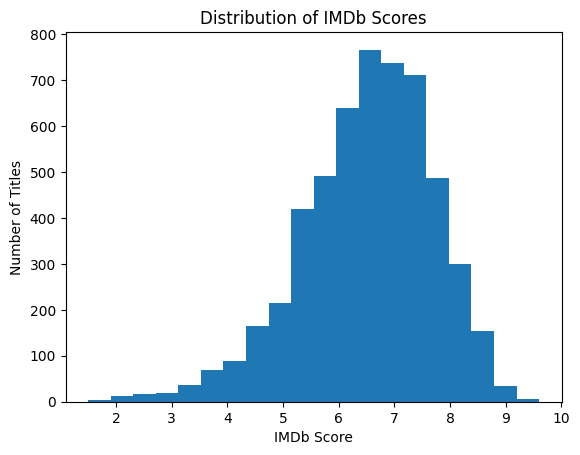

In [34]:
#score distribution

plt.hist(df['imdb_score'], bins=20)

plt.title("Distribution of IMDb Scores")
plt.xlabel("IMDb Score")
plt.ylabel("Number of Titles")

plt.show()

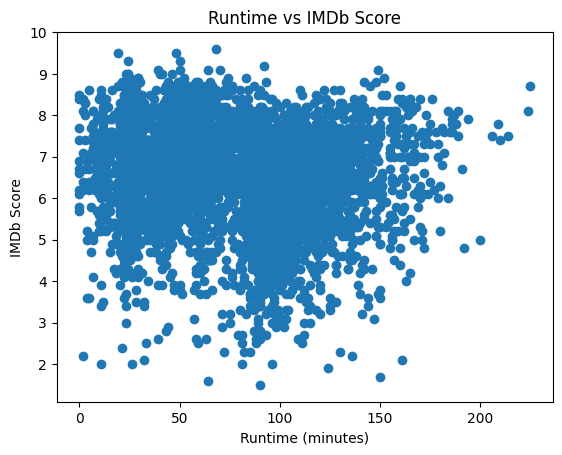

In [35]:
#runtime vs IMDb Score (scatter plot)

plt.scatter(df['runtime'], df['imdb_score'])

plt.title("Runtime vs IMDb Score")
plt.xlabel("Runtime (minutes)")
plt.ylabel("IMDb Score")

plt.show()

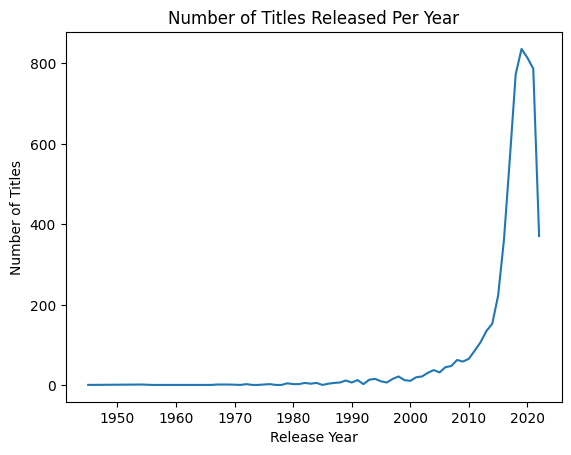

In [36]:
#movies released over the years

df['release_year'].value_counts().sort_index().plot(kind='line')

plt.title("Number of Titles Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

this line graph shows the number of Netflix titles released each year. It helps me to analyze the trends in content production and whether the number of releases has increased over time.

In [37]:
import os
print(os.listdir())

['train.py', '.ipynb_checkpoints', 'titles.csv', 'train.ipynb', 'Untitled.ipynb', 'train.csv']


In [38]:
import os
print(os.getcwd())

/home/ec2-user/SageMaker/project


In [39]:
import sagemaker
from sagemaker import get_execution_role

session = sagemaker.Session()
role = get_execution_role()

print("SageMaker ready")

SageMaker ready


In [40]:
from sagemaker.sklearn.estimator import SKLearn

estimator = SKLearn(
    entry_point="train.py",
    source_dir=".",
    role=role,
    instance_type="ml.m5.large",
    framework_version="0.23-1",
    py_version="py3"
)

In [41]:
import pandas as pd

#Load your dataset
df = pd.read_csv("titles.csv")

#Save as train.csv
df.to_csv("train.csv", index=False)

#Upload to S3
bucket = session.default_bucket()
prefix = "netflix-project"

train_path = session.upload_data(path="train.csv",
                                 bucket=bucket,
                                 key_prefix=prefix)

print("Data uploaded to:", train_path)

Data uploaded to: s3://sagemaker-us-east-1-258477568423/netflix-project/train.csv


In [42]:
estimator.fit({"train": train_path})

INFO:sagemaker:Creating training-job with name: sagemaker-scikit-learn-2026-04-12-05-02-13-764


2026-04-12 05:02:17 Starting - Starting the training job...
2026-04-12 05:02:32 Starting - Preparing the instances for training...
2026-04-12 05:02:58 Downloading - Downloading input data...
2026-04-12 05:03:23 Downloading - Downloading the training image...
2026-04-12 05:04:17 Training - Training image download completed. Training in progress.
2026-04-12 05:04:17 Uploading - Uploading generated training model2026-04-12 05:04:10,824 sagemaker-containers INFO     Imported framework sagemaker_sklearn_container.training
2026-04-12 05:04:10,827 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-04-12 05:04:10,864 sagemaker_sklearn_container.training INFO     Invoking user training script.
2026-04-12 05:04:11,228 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-04-12 05:04:11,239 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-04-12 05:04:11,251 sagemaker-training-toolkit INFO

In [43]:
predictor = estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large"
)

INFO:sagemaker:Creating model with name: sagemaker-scikit-learn-2026-04-12-05-05-44-563
INFO:sagemaker:Creating endpoint-config with name sagemaker-scikit-learn-2026-04-12-05-05-44-563
INFO:sagemaker:Creating endpoint with name sagemaker-scikit-learn-2026-04-12-05-05-44-563


------!

Model Training using AWS SageMaker

In this step, the machine learning model is trained using the Scikit-learn estimator in AWS SageMaker.

The training dataset is stored in Amazon S3.

The estimator.fit() function is used to start the training job.

SageMaker automatically provisions the required compute resources (ml.m5.large).

The training script (train.py) is executed inside the SageMaker environment.

The model learns patterns from the dataset and generates a trained model artifact.

The input data is passed using the "train" channel, which points to the S3 path of the dataset.

In [44]:
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

predictor.serializer = CSVSerializer()
predictor.deserializer = JSONDeserializer()

test_data = [[120, 2018, 8.0, 7.5, 80]]

prediction = predictor.predict(test_data)
print(prediction)

['MOVIE']


In this step, serializers and deserializers are used to handle communication between the notebook and the deployed SageMaker endpoint.

CSVSerializer is used to convert the input data into CSV format before sending it to the model endpoint.

JSONDeserializer is used to convert the output received from the model endpoint into a Python-readable format.

The model returns predictions in JSON format which is converted into python.

In [45]:
prediction = predictor.predict(test_data)
print(prediction)

['MOVIE']


In [46]:
#Short content - likely SHOW
[25, 2021, 7.2, 7.0, 55]

#Long content - likely MOVIE
[140, 2015, 8.5, 8.3, 95]

[140, 2015, 8.5, 8.3, 95]

This example has a long runtime and high ratings. The model predicts it as a MOVIE, which is consistent with typical movie characteristics.

In [47]:
test_data = [[120, 2018, 8.0, 7.5, 80],
             [40, 2021, 6.5, 6.8, 30],
             [150, 2005, 8.5, 8.3, 95]]

prediction = predictor.predict(test_data)

for i, pred in enumerate(prediction):
    print(f"Input {i+1}: {test_data[i]} → {pred}")

Input 1: [120, 2018, 8.0, 7.5, 80] → MOVIE


Here, I tested the model with a sample input having a runtime of 120 minutes, high IMDb score, and good popularity. The model correctly classifies it as a MOVIE, which aligns with real-world expectations

The model makes predictions based on patterns learned from numerical features such as runtime and ratings, rather than explicitly knowing whether the content is a movie or a show

These results confirm that the deployed model is working correctly and can perform real-time predictions using AWS SageMaker